<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/SVM_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (SVM) — Detailed Documentation

## 1. Geometric Intuition & Basic Terminology

Support Vector Machine (SVM), specifically used for classification as a **Support Vector Classifier (SVC)**, is a supervised machine learning algorithm designed to find an optimal decision boundary (hyperplane) that separates different classes of data.

* **Hyperplane / Decision Boundary:** The line (in 2D) or plane (in higher dimensions) that splits the data into distinct classes.
* **Marginal Planes (Bounding Planes):** Two parallel planes flanking the main decision boundary, passing through the closest data points of the respective classes.
* **Margin ($d$):** The perpendicular distance between the two marginal planes. Our goal is to maximize this margin, as a wider margin leads to better generalization and lower misclassification on unseen data ($d > d'$ is preferred).
* **Support Vectors:** The critical data points that lie exactly on the marginal planes. These specific points completely dictate the position and orientation of the decision boundary; removing other data points won't affect it.


## 2. Mathematical Intuition

To build the mathematical framework, we represent the geometry of a straight line or plane using vector notation.

A standard line equation $ax + by + c = 0$ can be rewritten using feature weights ($w_1, w_2$) and input features ($x_1, x_2$) as:

$$w_1x_1 + w_2x_2 + b = 0$$

Using vector transposition, this generalizes to:

$$w^Tx + b = 0$$

Where:
* $w$ is the weight vector perpendicular (normal) to the decision hyperplane.
* $b$ is the bias (intercept).

If $b = 0$, the plane passes directly through the origin ($w^Tx = 0$).

### Distance and Class Assignment
The decision boundary splits the feature space into positive and negative halves based on the sign of the projection:
* **Above / Positive side of the plane:** $d$ is positive $\implies w^Tx + b > 0$
* **Below / Negative side of the plane:** $d$ is negative $\implies w^Tx + b < 0$


## 3. Hard Margin SVM Formulation

In an ideal scenario where the data is perfectly linearly separable, we want to enforce zero misclassifications. This setup is known as a **Hard Margin SVM**.

We scale our parameters such that the two bounding marginal planes are defined by:
* **Positive Marginal Plane:** $w^Tx + b = +1$
* **Negative Marginal Plane:** $w^Tx + b = -1$


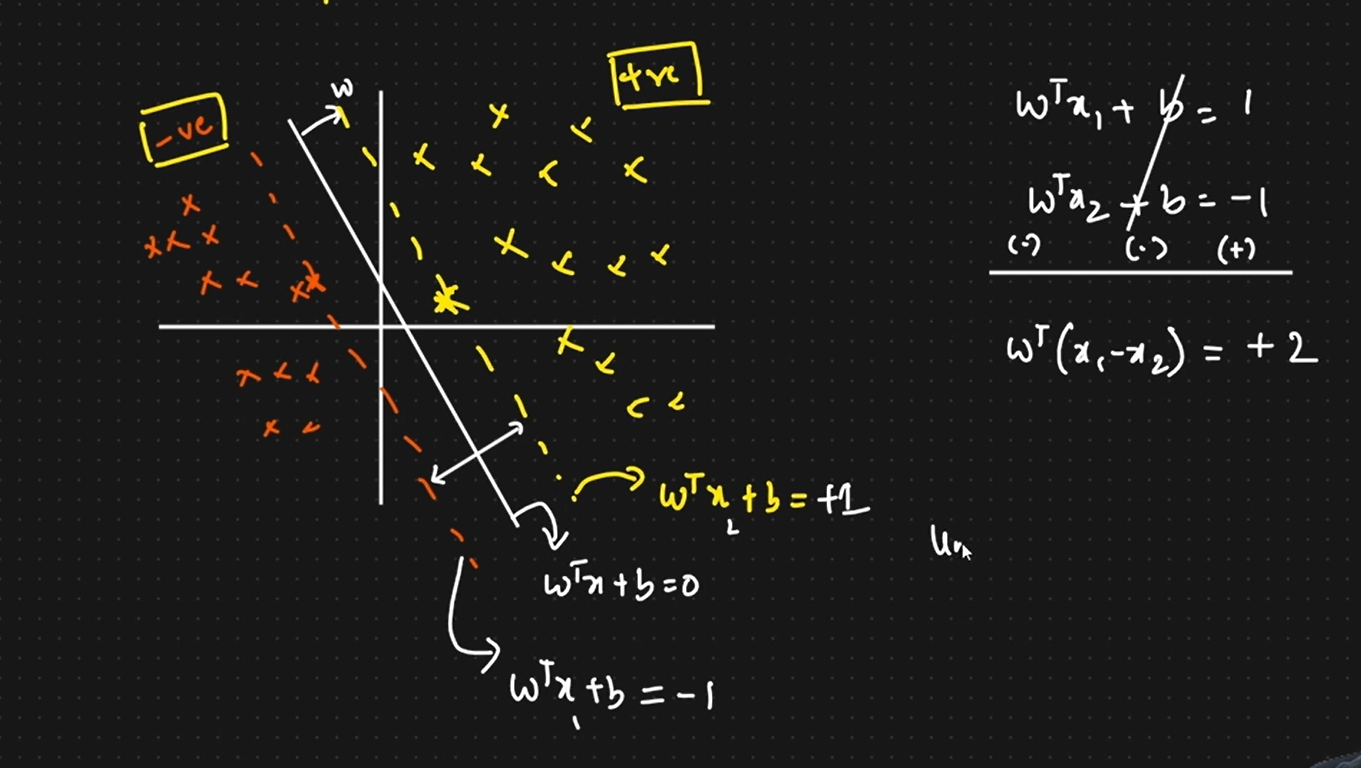


Subtracting these equations yields the vector distance equation $w^T(x_1 - x_2) = 2$. Normalizing by the magnitude of $w$ gives the exact total margin width:

$$\text{Margin Width} = \frac{2}{\|w\|}$$

### The Optimization Problem
To find the safest boundary, we must maximize this margin width $\frac{2}{\|w\|}$, which is mathematically equivalent to minimizing its reciprocal components:

$$\min_{w, b} \frac{\|w\|}{2}$$

$$\text{Subject to the constraint: } y_i(w^Tx_i + b) \ge 1 \quad \forall i$$

Where $y_i \in \{-1, +1\}$ represents the actual class label. For all correctly classified points, this constraint holds true.


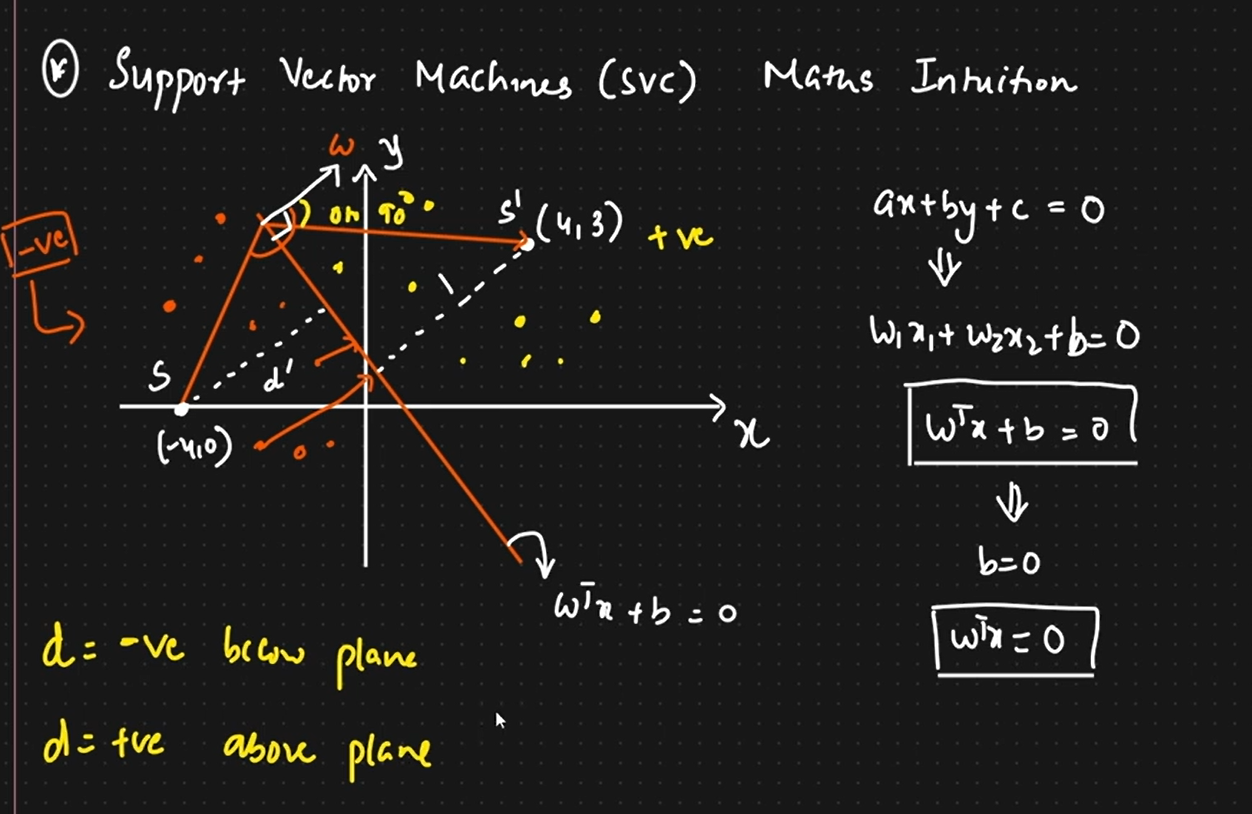



## 4. Soft Margin SVM & The Cost Function

Perfect linear separation is rarely possible in real-world datasets due to overlapping distributions and noise. A Hard Margin approach would fail or overfit drastically.

To handle overlapping data, we transition to a **Soft Margin SVM** by introducing a penalty system using slack variables ($\xi_i$) and a regularization hyperparameter ($C$).

### The Complete Optimization Objective (Cost Function)

$$\min_{w, b} \left( \frac{\|w\|}{2} + C \sum_{i=1}^{n} \xi_i \right)$$

This cost function consists of two competing terms:
* **Margin Maximization Term** ($\frac{\|w\|}{2}$): Tries to keep the margin as wide as possible.
* **Hinge Loss Term** ($C \sum_{i=1}^{n} \xi_i$): Quantifies errors and margin violations.
* **$\xi_i$ (Slack variable):** Measures the proportional distance of an incorrect or violating data point from its correct marginal plane.
* **$\sum_{i=1}^{n} \xi_i$:** The summation of distances of all misclassified or boundary-violating points.

### Understanding the Hyperparameter $C$
The value of $C$ dictates how strictly the algorithm avoids misclassifications:
* **High $C$:** Heavy penalty on misclassifications. The model acts like a Hard Margin SVM, focusing on keeping errors low at the expense of a narrower margin (High risk of overfitting).
* **Low $C$:** Tolerates more boundary violations to achieve a wider margin, prioritizing better generalizability (High risk of underfitting).


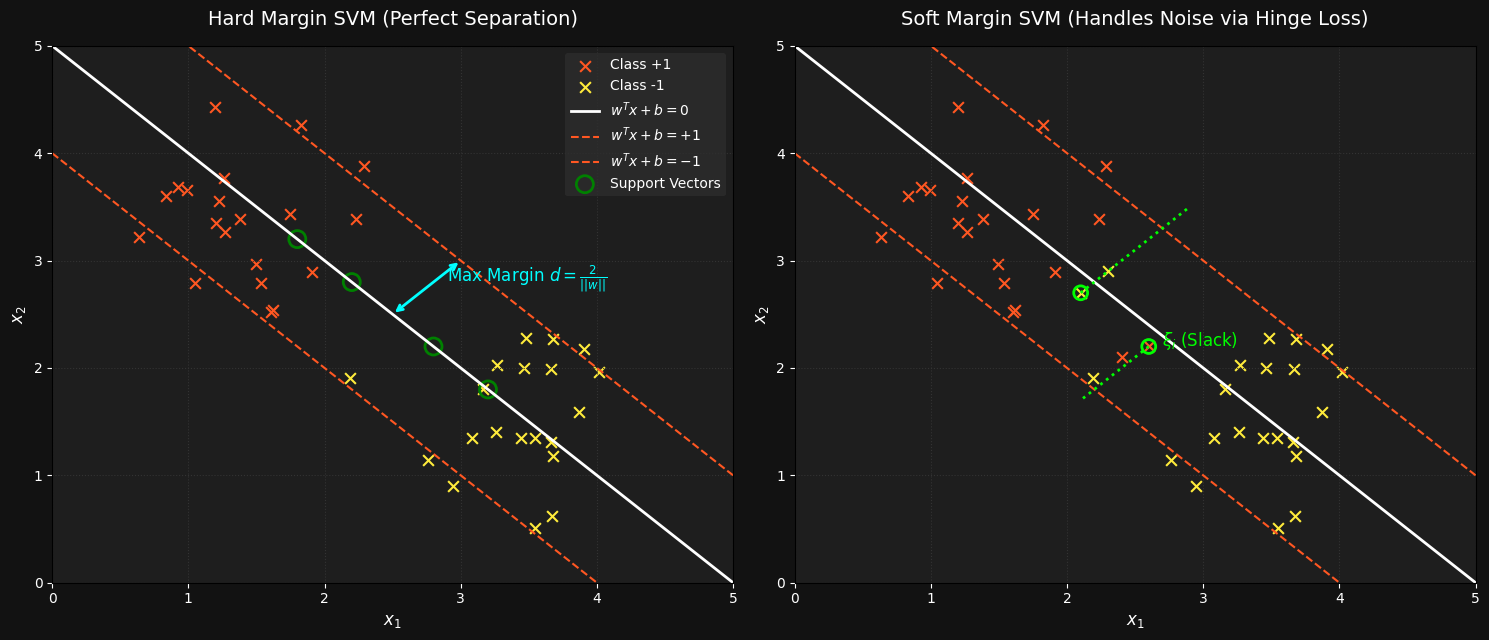


# Support Vector Regression (SVR) — Detailed Documentation

## 1. Geometric Intuition & Basic Terminology

Unlike traditional Support Vector Classifiers (SVC) that try to find a hyperplane separating data classes, Support Vector Regression (SVR) attempts to fit a hyperplane that encloses as many data points as possible within a specified distance metric.

Instead of maximizing the margin between two distinct classes, SVR defines a bounding tube (or envelope) around its regression prediction line.

* **SVR Hyperplane (Prediction Line):** The central regression line defined as $w^Tx + b$.
* **$\epsilon$ (Epsilon-Insensitive Tube):** A tube created by adding and subtracting an error threshold ($\epsilon$) from the hyperplane.
    * **Upper Boundary Line:** $w^Tx + b + \epsilon$
    * **Lower Boundary Line:** $w^Tx + b - \epsilon$
* **Epsilon ($\epsilon$):** Represents the marginal error. Any data point falling inside this tube incurs zero penalty or loss. SVR simply ignores errors smaller than $\epsilon$.
* **Slack Variables ($\xi_i$ and $\xi_i^*$):** Points that fall outside the $\epsilon$-insensitive tube are considered errors. The distance from the boundary of the tube to these external points is measured by slack variables ($\xi_i$ for points above, $\xi_i^*$ for points below).


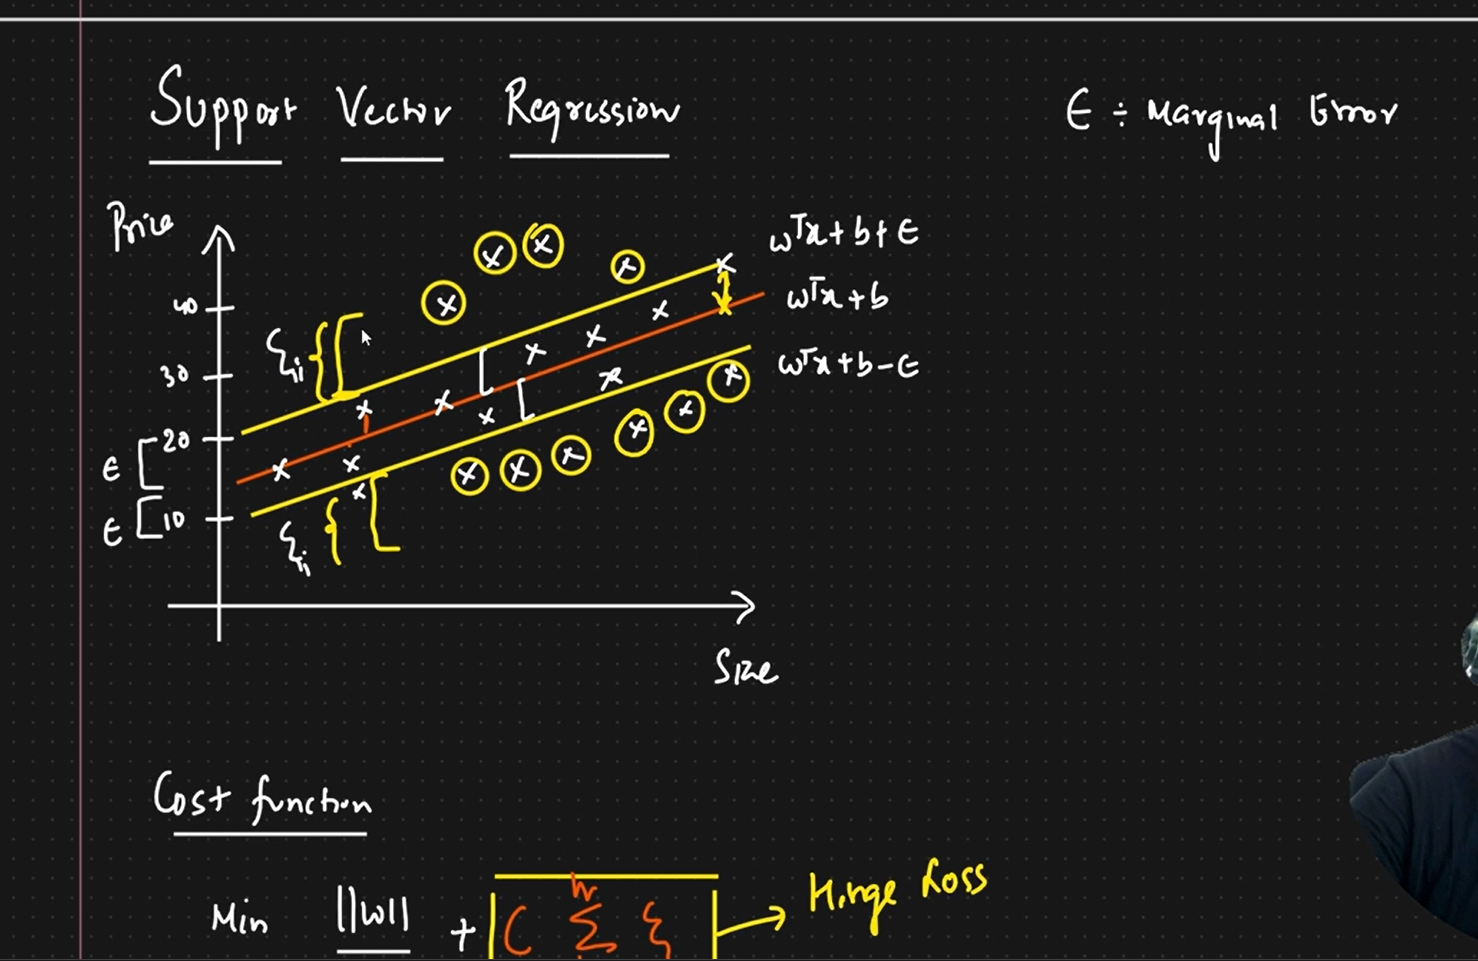



## 2. Cost Function and Constraints

The objective of SVR is to find a flat, generalized function that fits the trend without letting the prediction errors outside the tube become too large.

### The Complete Optimization Objective

$$\min_{w, b} \left( \frac{\|w\|}{2} + C \sum_{i=1}^{n} (\xi_i + \xi_i^*) \right)$$

This objective function balances two elements:
* **Flatness/Regularization ($\frac{\|w\|}{2}$):** Minimizing the norm of $w$ keeps the regression function as flat and smooth as possible to prevent overfitting.
* **Hinge Loss Optimization ($C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$):** Quantifies the penalty for points that cross outside the tube boundaries.

### Optimization Constraints
For every data point $(x_i, y_i)$, the absolute deviation between its true value $y_i$ and its predicted value $w^Tx_i + b$ must stay within the boundary of the tube plus its allowed slack:

$$\text{Subject to: } \begin{cases} y_i - (w^Tx_i + b) \le \epsilon + \xi_i \\ (w^Tx_i + b) - y_i \le \epsilon + \xi_i^* \\ \xi_i, \xi_i^* \ge 0 \end{cases}$$

* **Inside the tube:** $\implies \xi_i, \xi_i^* = 0$
* **Outside the tube:** $\implies \xi_i \text{ or } \xi_i^* > 0$ (proportional to its distance from the tube boundary).


## 3. Impact of Hyperparameters

### Hyperparameter $C$
The hyperparameter $C$ serves as a regularization tuning knob determining the tradeoff between the flatness of the model and its tolerance for points outside the $\epsilon$-tube.

* **High $C$ ($C \uparrow$):** The algorithm heavily penalizes errors outside the tube. The optimization prioritizes minimizing the Hinge Loss term, forcing the total loss function downward. This can lead to a less smooth, potentially overfitted line.
* **Low $C$ ($C \downarrow$):** The model is highly tolerant of data points slipping outside the tube, prioritizing a smoother, flat, and well-generalized global trend line.

### Hyperparameter $\epsilon$
* **High $\epsilon$:** Creates a wider tube. More points fall inside, resulting in fewer support vectors and a more generalized model.
* **Low $\epsilon$:** Creates a narrower tube. Fewer points fit inside, forcing the model to use more support vectors to match the data closely, which increases the risk of overfitting.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducible synthetic data
np.random.seed(25)

# 1. Generate Synthetic Data imitating a Price vs Size relationship
X = np.linspace(5, 45, 30)
# True line parameters
w_true = 0.65
b_true = 12.0
Y_true = w_true * X + b_true

# Add noise within epsilon tube, and explicitly inject high-variance outlier points
noise = np.random.uniform(-2, 2, size=X.shape)
Y = Y_true + noise

# Manually override certain indices to create distinct slack points outside the tube
outliers_up_idx = [8, 12, 14, 19]
outliers_down_idx = [9, 11, 16, 21, 22, 24]
Y[outliers_up_idx] += np.random.uniform(5, 9, len(outliers_up_idx))
Y[outliers_down_idx] -= np.random.uniform(5, 9, len(outliers_down_idx))

# 2. Define SVR Hyperplane and Epsilon Parameter
epsilon = 3.5
Y_hyperplane = Y_true + 1.5  # Slightly adjusted offset for visual baseline alignment
Y_tube_upper = Y_hyperplane + epsilon
Y_tube_lower = Y_hyperplane - epsilon

# 3. Separate Inside points vs Slack points for explicit ring styling
inside_mask = (Y <= Y_tube_upper) & (Y >= Y_tube_lower)
X_in, Y_in = X[inside_mask], Y[inside_mask]
X_out, Y_out = X[~inside_mask], Y[~inside_mask]

# --- Plot Configuration ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('#121212')

# Left Plot: SVR Geometric Visualization
ax1.set_facecolor('#1E1E1E')
ax1.scatter(X_in, Y_in, color='white', marker='x', s=60, label='Points inside tube (No Loss)')
ax1.scatter(X_out, Y_out, color='white', marker='x', s=60)
# Highlight points outside the epsilon band with yellow rings indicating slack variables
ax1.scatter(X_out, Y_out, s=140, facecolors='none', edgecolors='gold', linewidths=2, label=r'Slack Violations ($\xi_i$)')

# Draw SVR Prediction and Boundary lines
ax1.plot(X, Y_hyperplane, color='orangered', linewidth=2, label=r'Hyperplane ($w^Tx + b$)')
ax1.plot(X, Y_tube_upper, color='gold', linewidth=1.5, label=r'Upper Bound ($w^Tx + b + \epsilon$)')
ax1.plot(X, Y_tube_lower, color='gold', linewidth=1.5, label=r'Lower Bound ($w^Tx + b - \epsilon$)')

# Annotations for epsilon band width markers
ax1.annotate('', xy=(7, Y_hyperplane[2]), xytext=(7, Y_tube_upper[2]), arrowprops=dict(arrowstyle='<->', color='cyan', lw=1.5))
ax1.text(8, Y_hyperplane[2] + 1, r'$\epsilon$', color='cyan', fontsize=14, weight='bold')
ax1.annotate('', xy=(7, Y_hyperplane[2]), xytext=(7, Y_tube_lower[2]), arrowprops=dict(arrowstyle='<->', color='cyan', lw=1.5))
ax1.text(8, Y_hyperplane[2] - 2.5, r'$\epsilon$', color='cyan', fontsize=14, weight='bold')

# Draw a sample vertical indicator line showing a slack variable calculation
idx_sample = outliers_up_idx[1]
ax1.plot([X[idx_sample], X[idx_sample]], [Y_tube_upper[idx_sample], Y[idx_sample]], color='lime', linestyle='--', linewidth=2)
ax1.text(X[idx_sample]-2.5, Y[idx_sample]-1.5, r'$\xi_i$', color='lime', fontsize=14, weight='bold')

ax1.set_title("Support Vector Regression (SVR) Intuition", color='white', fontsize=14, pad=15)
ax1.set_xlabel("Size", color='white', fontsize=12)
ax1.set_ylabel("Price", color='white', fontsize=12)
ax1.tick_params(colors='white')
ax1.grid(True, color='#333333', linestyle=':')
ax1.legend(facecolor='#2D2D2D', edgecolor='none', labelcolor='white', loc='upper left')

# Right Plot: C vs Loss Function Relationship curve
ax2.set_facecolor('#1E1E1E')
C_vals = np.linspace(0.5, 10, 100)
loss_vals = 8 / (C_vals + 0.5) + 1  # Exponential style decay illustrating C increase vs hinge decay

ax2.plot(C_vals, loss_vals, color='gold', linewidth=2.5)
ax2.set_title("Relationship: Penalty Parameter C vs. Total Loss", color='white', fontsize=14, pad=15)
ax2.set_xlabel("Hyperparameter C", color='white', fontsize=12)
ax2.set_ylabel("Hinge Loss Function Value", color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.grid(True, color='#333333', linestyle=':')

# Annotate trend context text block
ax2.text(5, 6, r'$C \uparrow\uparrow \implies \text{Loss Function} \downarrow$', color='orangered', fontsize=13, weight='bold',
         bbox=dict(facecolor='#2D2D2D', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

ValueError: 
C \uparrow\uparrow \implies \text{Loss Function} \downarrow
                   ^
ParseFatalException: Unknown symbol: \implies, found '\'  (at char 19), (line:1, col:20)

Error in callback <function _draw_all_if_interactive at 0x7a019371f2e0> (for post_execute):


ValueError: 
C \uparrow\uparrow \implies \text{Loss Function} \downarrow
                   ^
ParseFatalException: Unknown symbol: \implies, found '\'  (at char 19), (line:1, col:20)

ValueError: 
C \uparrow\uparrow \implies \text{Loss Function} \downarrow
                   ^
ParseFatalException: Unknown symbol: \implies, found '\'  (at char 19), (line:1, col:20)

<Figure size 1500x650 with 2 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducible synthetic data
np.random.seed(25)

# 1. Generate Synthetic Data imitating a Price vs Size relationship
X = np.linspace(5, 45, 30)
# True line parameters
w_true = 0.65
b_true = 12.0
Y_true = w_true * X + b_true

# Add noise within epsilon tube, and explicitly inject high-variance outlier points
noise = np.random.uniform(-2, 2, size=X.shape)
Y = Y_true + noise

# Manually override certain indices to create distinct slack points outside the tube
outliers_up_idx = [8, 12, 14, 19]
outliers_down_idx = [9, 11, 16, 21, 22, 24]
Y[outliers_up_idx] += np.random.uniform(5, 9, len(outliers_up_idx))
Y[outliers_down_idx] -= np.random.uniform(5, 9, len(outliers_down_idx))

# 2. Define SVR Hyperplane and Epsilon Parameter
epsilon = 3.5
Y_hyperplane = Y_true + 1.5  # Slightly adjusted offset for visual baseline alignment
Y_tube_upper = Y_hyperplane + epsilon
Y_tube_lower = Y_hyperplane - epsilon

# 3. Separate Inside points vs Slack points for explicit ring styling
inside_mask = (Y <= Y_tube_upper) & (Y >= Y_tube_lower)
X_in, Y_in = X[inside_mask], Y[inside_mask]
X_out, Y_out = X[~inside_mask], Y[~inside_mask]

# --- Plot Configuration ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('#121212')

# Left Plot: SVR Geometric Visualization
ax1.set_facecolor('#1E1E1E')
ax1.scatter(X_in, Y_in, color='white', marker='x', s=60, label='Points inside tube (No Loss)')
ax1.scatter(X_out, Y_out, color='white', marker='x', s=60)
# Highlight points outside the epsilon band with yellow rings indicating slack variables
ax1.scatter(X_out, Y_out, s=140, facecolors='none', edgecolors='gold', linewidths=2, label=r'Slack Violations ($\xi_i$)')

# Draw SVR Prediction and Boundary lines
ax1.plot(X, Y_hyperplane, color='orangered', linewidth=2, label=r'Hyperplane ($w^Tx + b$)')
ax1.plot(X, Y_tube_upper, color='gold', linewidth=1.5, label=r'Upper Bound ($w^Tx + b + \epsilon$)')
ax1.plot(X, Y_tube_lower, color='gold', linewidth=1.5, label=r'Lower Bound ($w^Tx + b - \epsilon$)')

# Annotations for epsilon band width markers
ax1.annotate('', xy=(7, Y_hyperplane[2]), xytext=(7, Y_tube_upper[2]), arrowprops=dict(arrowstyle='<->', color='cyan', lw=1.5))
ax1.text(8, Y_hyperplane[2] + 1, r'$\epsilon$', color='cyan', fontsize=14, weight='bold')
ax1.annotate('', xy=(7, Y_hyperplane[2]), xytext=(7, Y_tube_lower[2]), arrowprops=dict(arrowstyle='<->', color='cyan', lw=1.5))
ax1.text(8, Y_hyperplane[2] - 2.5, r'$\epsilon$', color='cyan', fontsize=14, weight='bold')

# Draw a sample vertical indicator line showing a slack variable calculation
idx_sample = outliers_up_idx[1]
ax1.plot([X[idx_sample], X[idx_sample]], [Y_tube_upper[idx_sample], Y[idx_sample]], color='lime', linestyle='--', linewidth=2)
ax1.text(X[idx_sample]-2.5, Y[idx_sample]-1.5, r'$\xi_i$', color='lime', fontsize=14, weight='bold')

ax1.set_title("Support Vector Regression (SVR) Intuition", color='white', fontsize=14, pad=15)
ax1.set_xlabel("Size", color='white', fontsize=12)
ax1.set_ylabel("Price", color='white', fontsize=12)
ax1.tick_params(colors='white')
ax1.grid(True, color='#333333', linestyle=':')
ax1.legend(facecolor='#2D2D2D', edgecolor='none', labelcolor='white', loc='upper left')

# Right Plot: C vs Loss Function Relationship curve
ax2.set_facecolor('#1E1E1E')
C_vals = np.linspace(0.5, 10, 100)
loss_vals = 8 / (C_vals + 0.5) + 1  # Exponential style decay illustrating C increase vs hinge decay

ax2.plot(C_vals, loss_vals, color='gold', linewidth=2.5)
ax2.set_title("Relationship: Penalty Parameter C vs. Total Loss", color='white', fontsize=14, pad=15)
ax2.set_xlabel("Hyperparameter C", color='white', fontsize=12)
ax2.set_ylabel("Hinge Loss Function Value", color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.grid(True, color='#333333', linestyle=':')

# Annotate trend context text block
ax2.text(5, 6, r'$C \uparrow\uparrow \implies \text{Loss Function} \downarrow$', color='orangered', fontsize=13, weight='bold',
         bbox=dict(facecolor='#2D2D2D', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

ValueError: 
C \uparrow\uparrow \implies \text{Loss Function} \downarrow
                   ^
ParseFatalException: Unknown symbol: \implies, found '\'  (at char 19), (line:1, col:20)

Error in callback <function _draw_all_if_interactive at 0x7a019371f2e0> (for post_execute):


ValueError: 
C \uparrow\uparrow \implies \text{Loss Function} \downarrow
                   ^
ParseFatalException: Unknown symbol: \implies, found '\'  (at char 19), (line:1, col:20)

ValueError: 
C \uparrow\uparrow \implies \text{Loss Function} \downarrow
                   ^
ParseFatalException: Unknown symbol: \implies, found '\'  (at char 19), (line:1, col:20)

<Figure size 1500x650 with 2 Axes>